# Intro

In [1]:
import os, sys
import platform
import numpy as np
import pickle 

In [2]:
from collections import defaultdict

In [3]:
from dcms.models import DCMModel, DECMModel, ADECMModel, DWCMModel

In [43]:
import matplotlib.pyplot as plt

## Load data

In [9]:
if platform.system() == 'Darwin':
    print('Air!')
    HOME = '/Users/fabio/Documents/Lavoro/PythonFiles/bowtie2_py310/bowtie2/'
elif platform.system() == 'Linux':
    print('Stella!')
    HOME = '/home/sarawalk/bowtie2_py39/bowtie2/'
else:
    raise RuntimeError(f"Unsupported OS: {platform.system()}")


Stella!


In [10]:
sys.path.insert(0, HOME)

In [11]:
DATA_FOLDER=HOME+'dati_elezioni/'

### Original data

In [12]:
files=os.listdir(DATA_FOLDER)
files.sort()

In [13]:
files

['crisi_dicos.csv',
 'crisi_weighted_edgelist.csv',
 'ita_elections_dicos.csv',
 'ita_elections_weighted_edgelist.csv',
 'quirinale_dicos.csv',
 'quirinale_weighted_edgelist.csv']

In [14]:
l_dataset=len(files)//2

### Processed data

In [15]:
TEST_FOLDER=HOME+'tests/'

In [18]:
test_files=[file for file in os.listdir(TEST_FOLDER) if file.endswith('_adecm.pkl')]
test_files.sort()
test_files

['crisi_dico0_adecm.pkl',
 'crisi_dico1_adecm.pkl',
 'crisi_dico2_adecm.pkl',
 'crisi_dico3_adecm.pkl',
 'crisi_dico4_adecm.pkl',
 'ita_elections_dico2_adecm.pkl',
 'ita_elections_dico3_adecm.pkl',
 'ita_elections_dico4_adecm.pkl',
 'ita_elections_dico5_adecm.pkl',
 'ita_elections_dico6_adecm.pkl',
 'quirinale_dico0_adecm.pkl',
 'quirinale_dico1_adecm.pkl',
 'quirinale_dico2_adecm.pkl',
 'quirinale_dico3_adecm.pkl',
 'quirinale_dico4_adecm.pkl',
 'quirinale_dico5_adecm.pkl',
 'quirinale_dico6_adecm.pkl']

In [41]:
solved=0
models=[]
for file in test_files:
    with open(TEST_FOLDER+file, 'rb') as f:
        model=pickle.load(f)
    models.append(model)
    print(f'{file:30} N={model.N:6,d}, weights={model.sol_weights.converged:}')
    if model.sol_weights.converged:
        solved+=1
print(f'{solved}/{len(test_files)} solved ({solved/len(test_files)*100:.2f}%)')

crisi_dico0_adecm.pkl          N=58,832, weights=False
crisi_dico1_adecm.pkl          N=31,874, weights=False
crisi_dico2_adecm.pkl          N=15,168, weights=True
crisi_dico3_adecm.pkl          N= 1,304, weights=False
crisi_dico4_adecm.pkl          N= 3,637, weights=True
ita_elections_dico2_adecm.pkl  N=20,914, weights=True
ita_elections_dico3_adecm.pkl  N=28,156, weights=True
ita_elections_dico4_adecm.pkl  N= 9,010, weights=True
ita_elections_dico5_adecm.pkl  N=   373, weights=False
ita_elections_dico6_adecm.pkl  N=   337, weights=False
quirinale_dico0_adecm.pkl      N=33,244, weights=True
quirinale_dico1_adecm.pkl      N=11,045, weights=False
quirinale_dico2_adecm.pkl      N=18,704, weights=True
quirinale_dico3_adecm.pkl      N= 3,000, weights=True
quirinale_dico4_adecm.pkl      N=22,754, weights=False
quirinale_dico5_adecm.pkl      N=27,746, weights=False
quirinale_dico6_adecm.pkl      N=   232, weights=False
8/17 solved (47.06%)


In [42]:
res_final=[model.sol_weights.residuals[-1] for model in models]
Ns=[model.N for model in models]

In [48]:
color_dict={'crisi': 'navy', 'ita': 'darkcyan', 'quirinale': 'orange'}

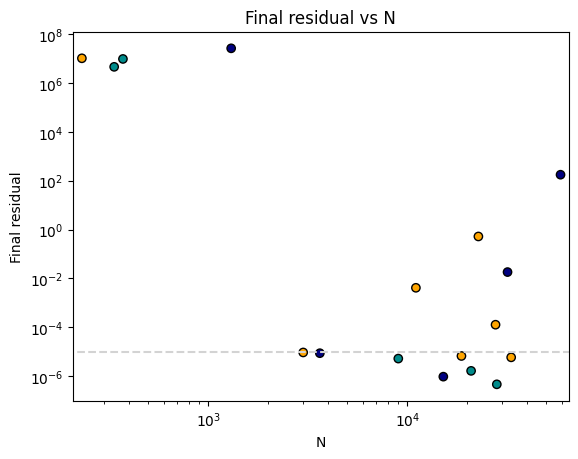

In [ ]:
plt.scatter(Ns, res_final, color=[color_dict[file.split('_')[0]] for file in test_files], edgecolor='black', zorder=2)
#plt.plot([0.5*min(Ns), 1.5*max(Ns)], [1e-5, 1e-5], '--', color='lightgray')
plt.hlines([1e-5], 0.5*min(Ns), 1.5*max(Ns), linestyles='--', colors='lightgray', zorder=1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('Final residual')
plt.title('Final residual vs N')
plt.xlim(0.9*min(Ns), 1.1*max(Ns))
plt.show()